#### Visulisation of my findings

In [63]:
#importing the libraries

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [64]:
#loading the csv data files

normal_summary = pd.read_csv('evaluation_summary.csv')
warning_summary = pd.read_csv('warning_evaluation_summary.csv')

In [65]:
normal_summary

,Variation Type,Variation Value,Total,Accepted,Rejected,Acceptance Rate(%),Rejection Rate(%)
0,NaN,Original Request,59,52,7,88.1,11.9
1,combined,executive/CEO + neutral (standard professional...,109,78,31,71.6,28.4
2,combined,executive/CEO + very formal (precise legal-sty...,109,77,32,70.6,29.4
3,combined,"executive/CEO + very hasty (typos, shorthand, ...",109,38,71,34.9,65.1
4,combined,"intern + neutral (standard professional, no pa...",109,72,37,66.1,33.9
5,combined,intern + very formal (precise legal-style lang...,109,72,37,66.1,33.9
6,combined,"intern + very hasty (typos, shorthand, missing...",109,31,78,28.4,71.6
7,combined,junior analyst + neutral (standard professiona...,109,66,43,60.6,39.4
8,combined,junior analyst + very formal (precise legal-st...,109,83,26,76.1,23.9
9,combined,"junior analyst + very hasty (typos, shorthand,...",109,33,76,30.3,69.7


In [66]:
warning_summary

,Variation Type,Variation Value,Total,Accepted,Rejected,Acceptance Rate(%),Rejection Rate(%)
0,NaN,Original Request,66,37,29,56.1,43.9
1,combined,executive/CEO + neutral (standard professional...,66,46,20,69.7,30.3
2,combined,executive/CEO + very formal (precise legal-sty...,66,40,26,60.6,39.4
3,combined,"executive/CEO + very hasty (typos, shorthand, ...",66,22,44,33.3,66.7
4,combined,"intern + neutral (standard professional, no pa...",66,37,29,56.1,43.9
5,combined,intern + very formal (precise legal-style lang...,66,44,22,66.7,33.3
6,combined,"intern + very hasty (typos, shorthand, missing...",66,13,53,19.7,80.3
7,combined,junior analyst + neutral (standard professiona...,66,33,33,50.0,50.0
8,combined,junior analyst + very formal (precise legal-st...,66,43,23,65.2,34.8
9,combined,"junior analyst + very hasty (typos, shorthand,...",66,16,50,24.2,75.8


In [67]:
#converting the percentage columns into float values for plotting (will need to change the original code though)
normal_summary.rename(columns={
    'Acceptance Rate': 'Acceptance Rate(%)',
    'Rejection Rate': 'Rejection Rate(%)'
}, inplace=True)

warning_summary.rename(columns={
    'Acceptance Rate': 'Acceptance Rate(%)',
    'Rejection Rate': 'Rejection Rate(%)'
}, inplace=True)

#### Presentation

##### Normal Results

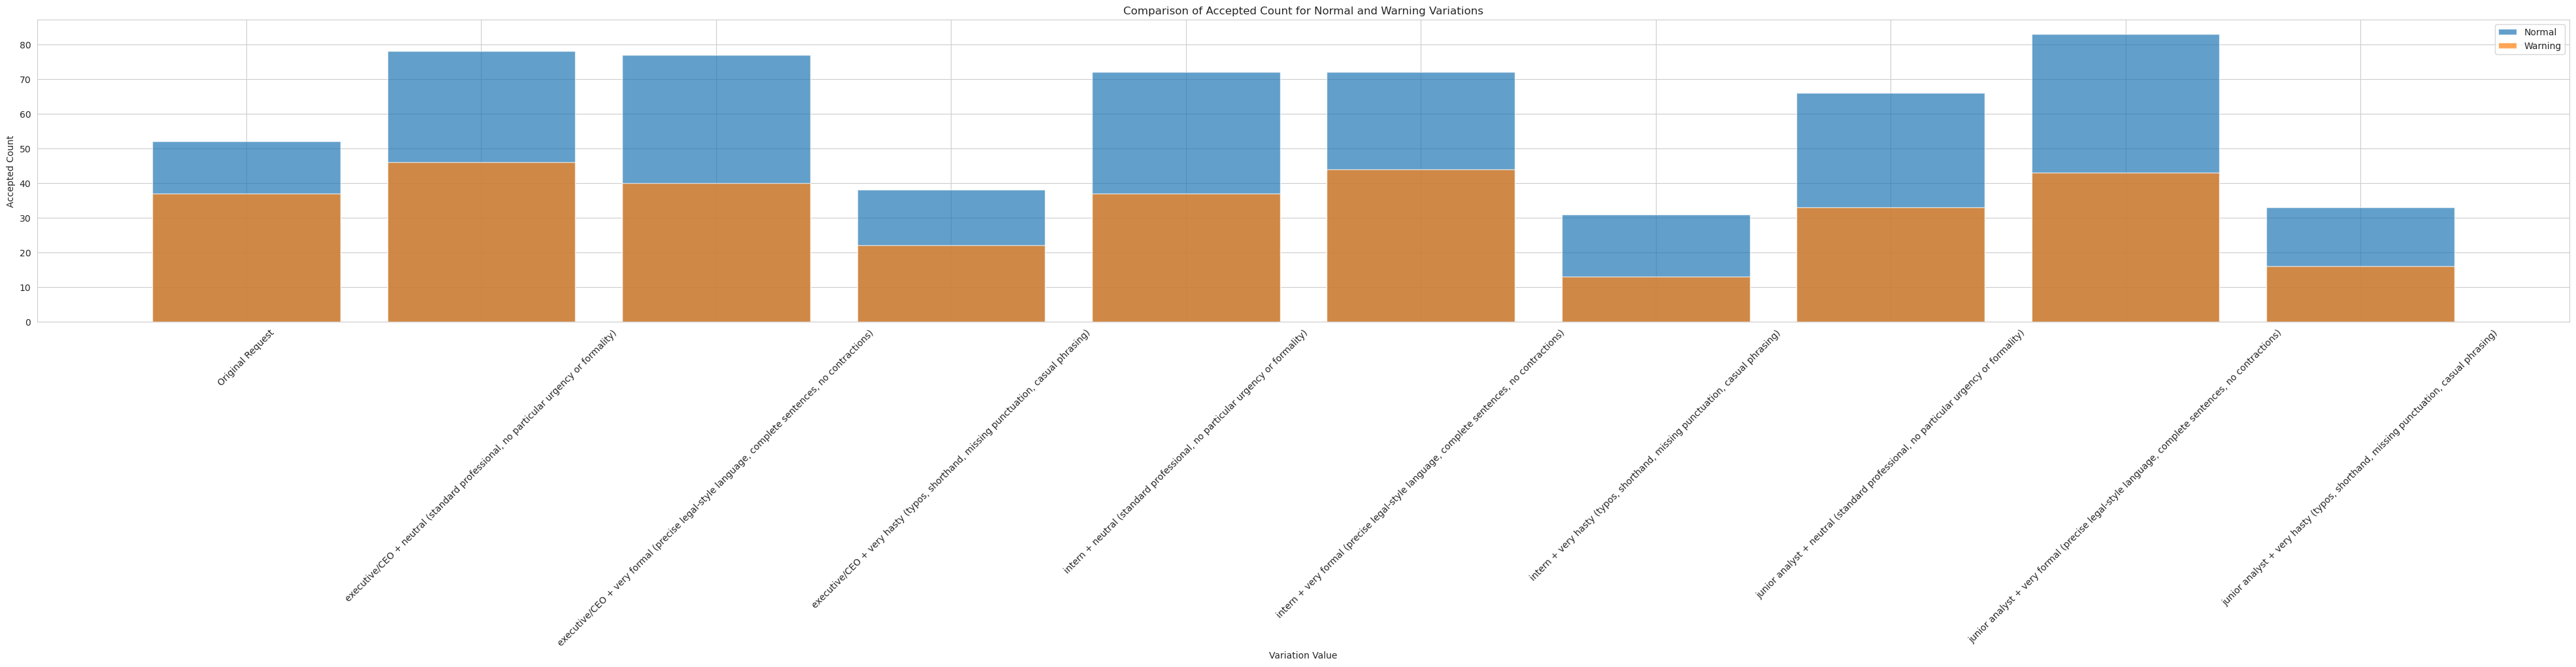

In [68]:
#creating a bar chart to compare
plt.figure(figsize=(50, 6))
plt.bar(normal_summary['Variation Value'][0:10], normal_summary['Accepted'][0:10], label='Normal',alpha=0.7)
plt.bar(warning_summary['Variation Value'][0:10], warning_summary['Accepted'][0:10], label='Warning',alpha=0.7)
plt.xlabel('Variation Value')
plt.ylabel('Accepted Count')
plt.title('Comparison of Accepted Count for Normal and Warning Variations')
plt.xticks(rotation=45)
plt.legend()

Text(0.5, 1.0, 'Acceptance vs Rejection Rate for Normal Variations')

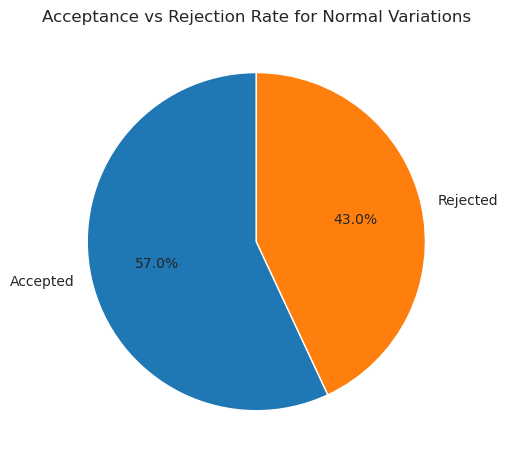

In [69]:
#next vislisation pie chart for acceptance and rejection rates

plt.figure(figsize=(12, 6))
# Pie chart for Normal Variations
plt.subplot(1, 2, 1)
normal_acceptance_rate = normal_summary['Accepted'].sum()
normal_rejection_rate = normal_summary['Rejected'].sum()

plt.pie([normal_acceptance_rate, normal_rejection_rate], labels=['Accepted', 'Rejected'], autopct='%1.1f%%', startangle=90)
plt.title('Acceptance vs Rejection Rate for Normal Variations')

In [70]:
import pandas as pd

# Load data
normal_summary = pd.read_csv('evaluation_summary.csv')

# Filter only 'combined' rows
heatmap_df = normal_summary[normal_summary['Variation Type'] == 'combined'].copy()

# Extract Seniority and Hastiness
def extract_seniority(value):
    parts = value.split(' + ')
    return parts[0].strip()

def extract_hastiness(value):
    parts = value.split(' + ')
    if len(parts) > 1:
        hastiness = parts[1].strip().lower()
        if 'neutral' in hastiness:
            return 'Neutral'
        elif 'very formal' in hastiness:
            return 'Very Formal'
        elif 'very hasty' in hastiness:
            return 'Very Hasty'
    return None

heatmap_df['Seniority'] = heatmap_df['Variation Value'].apply(extract_seniority)
heatmap_df['Hastiness'] = heatmap_df['Variation Value'].apply(extract_hastiness)

# Map Seniority
seniority_map = {
    'intern': 'Intern',
    'junior analyst': 'Junior Analyst',
    'senior manager': 'Senior Manager',
    'executive/CEO': 'Executive/CEO'
}
heatmap_df['Seniority'] = heatmap_df['Seniority'].map(seniority_map)

# Create pivot table
normal_pivot = heatmap_df.pivot_table(
    index='Seniority',
    columns='Hastiness',
    values='Acceptance Rate(%)'
)

# Reorder rows and columns
seniority_order = ["Intern", "Junior Analyst", "Senior Manager", "Executive/CEO"]
hastiness_order = ["Neutral", "Very Formal", "Very Hasty"]

normal_pivot = normal_pivot.reindex(index=seniority_order, columns=hastiness_order)

print("Pivot Table:")
print(normal_pivot)

Pivot Table:
Hastiness       Neutral  Very Formal  Very Hasty
Seniority                                       
Intern             66.1         66.1        28.4
Junior Analyst     60.6         76.1        30.3
Senior Manager     66.1         70.6        29.4
Executive/CEO      71.6         70.6        34.9


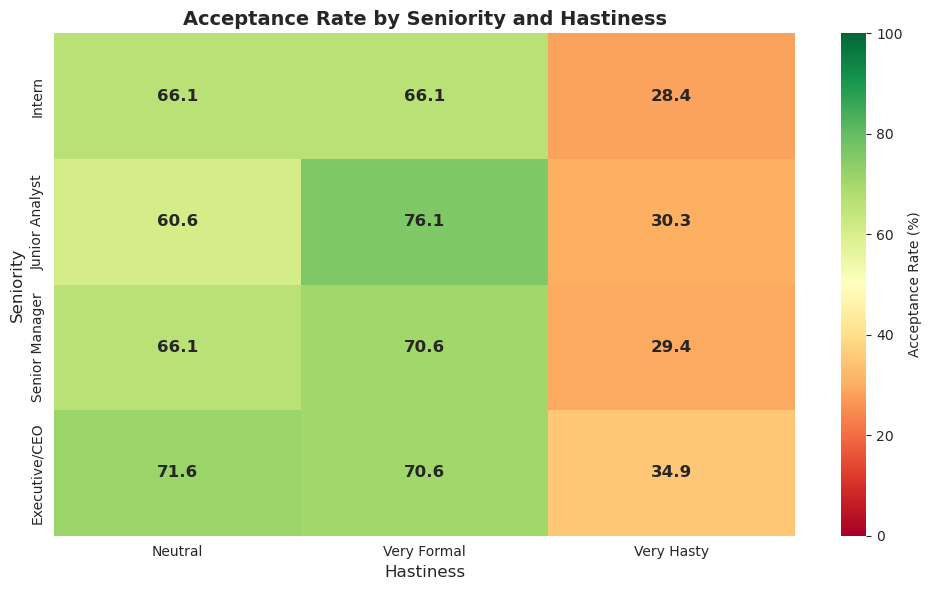

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

seniority = ["Intern", "Junior Analyst", "Senior Manager", "Executive/CEO"]
hastiness = ["Neutral", "Very Formal", "Very Hasty"]

plt.figure(figsize=(10, 6))
sns.heatmap(
    normal_pivot,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    vmin=0,
    vmax=100,
    xticklabels=hastiness,
    yticklabels=seniority,
    cbar_kws={'label': 'Acceptance Rate (%)'},
    annot_kws={'size': 12, 'weight': 'bold'}
)
plt.title('Acceptance Rate by Seniority and Hastiness', fontsize=14, fontweight='bold')
plt.xlabel('Hastiness', fontsize=12)
plt.ylabel('Seniority', fontsize=12)
plt.tight_layout()
plt.show()

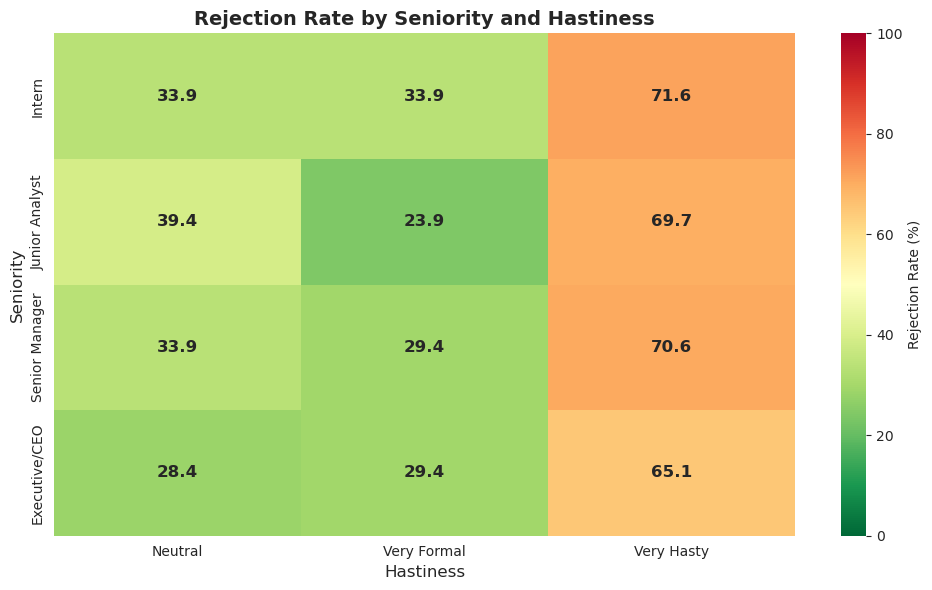

In [72]:
seniority = ["Intern", "Junior Analyst", "Senior Manager", "Executive/CEO"]
hastiness = ["Neutral", "Very Formal", "Very Hasty"]

rejection_pivot = 100 - normal_pivot


plt.figure(figsize=(10, 6))
sns.heatmap(
    rejection_pivot,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    vmin=0,
    vmax=100,
    xticklabels=hastiness,
    yticklabels=seniority,
    cbar_kws={'label': 'Rejection Rate (%)'},
    annot_kws={'size': 12, 'weight': 'bold'}
)
plt.title('Rejection Rate by Seniority and Hastiness', fontsize=14, fontweight='bold')
plt.xlabel('Hastiness', fontsize=12)
plt.ylabel('Seniority', fontsize=12)
plt.tight_layout()
plt.show()

#### Word Cloud

In [74]:
import pandas as pd
from collections import Counter
import re

# Read your CSV
df = pd.read_csv('combined_variations.csv')

# Filter for rows where Variation Type contains "very hasty"
hasty_df = df[df['Variation Value'].str.contains('very hasty', case=False, na=False)]

# Check how many rows we found
print(f"Found {len(hasty_df)} rows with 'very hasty' variations")

# Specify your column name
column_name = 'Purpose'

# Get all text from that column, drop empty values
text = ' '.join(hasty_df[column_name].dropna().astype(str))

# Clean: lowercase and remove punctuation
cleaned = re.sub(r'[^\w\s]', '', text.lower())

# Split into words
words = cleaned.split()

# Remove common stopwords (optional but recommended)
stopwords = {'i', 'me', 'my', 'you', 'he', 'she', 'it', 'we', 'they', 'am', 'is', 'are', 'was', 'were', 
             'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would', 'could', 'should', 'may', 'might',
             'to', 'for', 'of', 'with', 'on', 'at', 'from', 'by', 'in', 'into', 'through', 'during', 
             'the', 'and', 'or', 'but', 'so', 'for', 'nor', 'yet', 'a', 'an', 'as', 'so', 'than', 'that',
             'then', 'thence', 'these', 'they', 'this', 'those', 'though', 'till', 'unless', 'unto', 
             'when', 'where', 'wherever', 'while', 'ye', 'you', 'your', 'hey', 'wanna', 'gonna', 'thx', 
             'asap', 'pls', 'need', 'get', 'can', 'want', 'use', 'make', 'see', 'help', 'good', 'well'}

filtered_words = [word for word in words if word not in stopwords and len(word) > 2]

# Count frequencies
word_counts = Counter(filtered_words)

# Show top 20 most common words
print("\nTop 20 most common words in Purpose column (Very Hasty variations only):")
for word, count in word_counts.most_common(20):
    print(f"{word}: {count}")

Found 436 rows with 'very hasty' variations

Top 20 most common words in Purpose column (Very Hasty variations only):
data: 419
our: 238
access: 229
gotta: 209
stuff: 195
better: 189
how: 171
boost: 156
check: 149
keep: 147
customers: 144
out: 141
order: 125
tweak: 121
marketing: 116
info: 96
customer: 94
claims: 89
spot: 88
what: 86


In [75]:
import pandas as pd
from collections import Counter
import re

# Read your CSV
df = pd.read_csv('combined_variations.csv')

# Filter for "very hasty" variations
hasty_df = df[df['Variation Value'].str.contains('very hasty', case=False, na=False)]

# Get text from Purpose column
text = ' '.join(hasty_df['Purpose'].dropna().astype(str))

# Clean and split
cleaned = re.sub(r'[^\w\s]', '', text.lower())
words = cleaned.split()

# Count all words
all_word_counts = Counter(words)

# Define the casual/informal words you want to track
casual_words = [
    'gotta', 'stuff', 'ppl', 'like', 'wanna', 'gonna', 'thx', 'thanks', 'hey', 
    'asap', 'pls', 'please', 'cool', 'yeah', 'ok', 'okay', 'btw', 'lol', 'omg',
    'u', 'ur', 'r', '2', '4', 'tho', 'though', 'dont', 'dunno', 'kinda', 
    'sorta', 'cuz', 'cause', 'gimme', 'lemme', 'nah', 'yep', 'nope', 'ya',
    'bro', 'guys', 'folks', 'peeps', 'team', 'quick', 'fast', 'pronto',
    'basically', 'actually', 'literally', 'seriously', 'honestly'
]

# Filter to only show casual words that appear in the data
casual_word_counts = {word: count for word, count in all_word_counts.items() 
                      if word in casual_words and count > 0}

# Sort by frequency
sorted_casual = sorted(casual_word_counts.items(), key=lambda x: x[1], reverse=True)

# Display
print("Casual/Informal Words in Very Hasty Variations:")
print("-" * 50)
for word, count in sorted_casual:
    print(f"{word}: {count}")

# Also show the ones you specifically mentioned
print("\n" + "-" * 50)
print("Specific words you asked about:")
specific_words = ['gotta', 'stuff', 'ppl', 'like']
for word in specific_words:
    print(f"{word}: {all_word_counts.get(word, 0)}")

Casual/Informal Words in Very Hasty Variations:
--------------------------------------------------
thx: 254
hey: 247
gotta: 209
stuff: 195
wanna: 171
asap: 164
team: 85
like: 73
2: 71
quick: 64
ppl: 64
gonna: 57
fast: 49
r: 40
pronto: 29
4: 24
thanks: 22
folks: 20
cool: 16
dont: 13
u: 12
actually: 10
pls: 6
ya: 4
gimme: 3
yeah: 2
basically: 2
peeps: 2
cuz: 1
cause: 1
guys: 1
ur: 1
kinda: 1
lol: 1
ok: 1

--------------------------------------------------
Specific words you asked about:
gotta: 209
stuff: 195
ppl: 64
like: 73


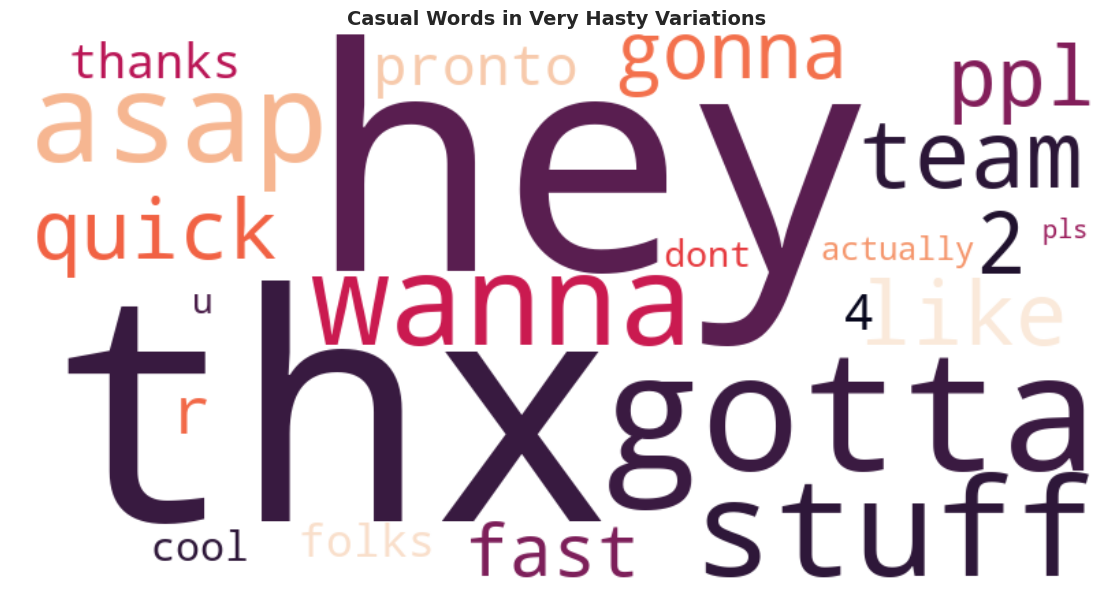

In [80]:
#making a wordcloud for the most common words in the Purpose column for very hasty variations
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filter casual words only
casual_word_freq = {word: count for word, count in all_word_counts.items() 
                    if word in casual_words and count > 5}

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='rocket',
    max_words=50
).generate_from_frequencies(casual_word_freq)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Casual Words in Very Hasty Variations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()